# Goals

Marekt Share vs BSR analysis
- find a statistical evidene before building up a model

# Libraries

In [116]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
from interpret import set_visualize_provider, show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor

set_visualize_provider(InlineProvider())

In [120]:
from datetime import date

## Utility functions

In [121]:
seed = 42

In [122]:
def plotting_predictions(ts_true,ts_pred,fig_title):
    plt.figure(figsize=(12,8))
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    
    plt.plot(ts_true,'-bo',label='Actual value')
    plt.plot(ts_pred,'-r^',label='Prediction value')
    
    plt.legend(loc='upper left',fontsize=15)
    plt.title(fig_title,fontsize=18)
    
    #rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    #plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2  : %.2f" % (rmse,mape,r2), \
    #     bbox={'facecolor':'w','pad':5},
    #     ha="right", va="top", transform=plt.gca().transAxes,fontsize=15)
    rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2   : %.2f" % (rmse,mape,r2), \
         bbox={'facecolor':'w','pad':5},
         ha="left", va="top", transform=plt.gca().transAxes,fontsize=15)
    
    plt.show()

In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_time_series(y_true, y_pred,verbose=True):
    '''
    Compute the MAE and MSE metrics from sklearn.metrics
    @param y_true: (list) list of the true values
    @param y_pred: (list) list of predicted values
    @return rmse,mape,mae: (float), (float) values of metrics RMSE,MAPE, MAE
    '''
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 2) 
    
    y_true_nz = y_true[(y_true!=0.0)] # non-zero true values (See denom.)
    mape = round(np.mean(np.abs((y_true_nz - y_pred[y_true_nz.index]) / y_true_nz)) * 100,2)
    
    #mae = round(mean_absolute_error(y_true, y_pred),2)
    r2 =  round(r2_score(y_true, y_pred), 2)
    
    if verbose:
        print(f"RMSE : {rmse}")
     #  print(f"MAE : {mae}")
        print(f"MAPE : {mape}")   
        print(f"R2   : {r2}")
    return rmse,mape,r2

# Data Wrangling

In [124]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"
import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

In [125]:
bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [157]:
#st_sql = """
#select * from wook.stct_atlas_sales_zinus;
#"""
#df_st = bqclient.query(st_sql).to_dataframe()
#df_st = df_st.drop_duplicates()

ms_sql = """
select * from wook.stct_atlas_sales_ms_weekly;
"""
bsr_sql = """
select * from wook.bsr_share_weekly_zinus;
"""

df_ms = bqclient.query(ms_sql).to_dataframe()
df_ms = df_ms.drop_duplicates()
df_bsr = bqclient.query(bsr_sql).to_dataframe()
df_bsr = df_bsr.drop_duplicates()

## Category & Subcategory

### Category

In [158]:
df_ms[['Category']].value_counts()

Category                                    
Pet Beds & Furniture                            2805
Bed Pillows & Pillowcases                       2688
Kitchen Accessories                             2496
Clothing & Closet Storage                       2304
Car Accessories                                 2112
Office Cabinets, Shelves & Storage              1728
Living Room Furniture                           1638
Shelves & Accessories                           1536
Office Desks & Workstations                     1536
Accent Furniture                                1344
Bed Accessories                                 1152
Patio Furniture & Accessories                   1152
Beds & Bed Frames                                976
Area Rugs, Runners & Pads                        960
Mattress Accessories                             960
TV Mounts & Stands                               960
Dining Chairs, Tables & Sets                     960
Mattresses                                       768
E

### Projection to BSR table

In [159]:
df_ms[['Category','SubCategory']].value_counts()

Category                                      SubCategory           
Accent Furniture                              End Tables                192
Entryway Furniture                            Entry Tables              192
Living Room Furniture                         Living Room Table Sets    192
Mattress Accessories                          Electric Mattress Pads    192
                                              Mattress Encasements      192
                                                                       ... 
Classroom Furniture                           School Seating              1
Musical Instruments, Equipment & Accessories  Hand Percussion             1
Office Chairs                                 Other Chairs                1
Bakeware                                      Tart Pans                   1
Candy                                         Marshmallows                1
Length: 192, dtype: int64

In [160]:
sum(df_ms.Category=='Beds & Bed Frames')

976

In [163]:
map_dict = {
    'Mattresses_Mattresses':'1. Mattresses',
      'Beds & Bed Frames_Box Springs':'2. Box Springs',
      'Beds & Bed Frames_Bed Frames':'3. Bed Frames',
      'Beds & Bed Frames_Beds':'4. Beds',
      'Mattress Accessories_Mattress Toppers':'5. Mattress Toppers',
      'Living Room Furniture_Living Room Sofas & Couches':'6. Sofas & Couches',
      'Patio Furniture & Accessories_Patio Furniture Sets':'7. Patio Conversation Sets',
      'Living Room Furniture_Living Room Table Sets':'8. Living Room Table Sets'
}

In [161]:
CatAndSubCat = df_ms.Category+'_'+df_ms.SubCategory

In [162]:
CatAndSubCat.unique()

array(['Candy_Marshmallows',
       'Skin Care Devices, Tools & Equipment_Salon & Spa Equipment',
       'Office Chairs_Other Chairs',
       'Home Bar Furniture_Bar & Counter Stools',
       'Classroom Furniture_School Seating',
       'Office Tables & Sets_Table & Chair Sets',
       'Office Chairs_Guest & Reception Chairs',
       'Game & Recreation Room Furniture_Folding Tables',
       'Commercial Kitchen Equipment_Restaurant Furniture',
       'Game & Recreation Room Furniture_Folding Chairs',
       'Home Bar Furniture_Bar Tables',
       'Automotive Cargo Bed Covers_Automotive Tonneau Covers',
       'Office Chairs_Stacking Chairs', 'Bakeware_Tart Pans',
       'Bakeware_Round Cake Pans', 'Bakeware_Baking & Cookie Sheets',
       'Bakeware_Bundt Pans', 'Grill Parts & Accessories_Grids & Grates',
       'Grills & Outdoor Cooking_Grilling Cookware',
       'Blankets & Quilts_Throws & Throw Blankets',
       'Steamers & Pasta Pots_Steamers',
       'Kitchen Storage & Organization_

In [164]:
df_ms['bsr_ctgry_label'] = [map_dict[x] if x in map_dict.keys() else np.nan for x in CatAndSubCat]

In [165]:
df_ms.bsr_ctgry_label.value_counts()

1. Mattresses                 192
3. Bed Frames                 192
4. Beds                       192
2. Box Springs                192
5. Mattress Toppers           192
6. Sofas & Couches            192
8. Living Room Table Sets     192
7. Patio Conversation Sets    192
Name: bsr_ctgry_label, dtype: int64

In [166]:
df_bsr.bsr_ctgry_label.value_counts()

1. Mattresses           46
2. Box Springs          46
3. Bed Frames           46
4. Beds                 46
5. Mattress Toppers     46
6. Sofas & Couches      46
9. Home Office Desks    46
Name: bsr_ctgry_label, dtype: int64

## Subsetting a few categories

Stick to 
- Mattresses
- Beds
- Bed Frames

In [167]:
df_ms['year_week'] = [x.date() for x in pd.to_datetime(df_ms.WeekEnding)]
df_ms.drop(['Category','SubCategory','WeekID','yr','wk','WeekEnding','mth'],axis=1,inplace=True)

In [168]:
df_ms.dropna(inplace=True)
df_ms.shape

(1536, 3)

In [169]:
df_ms

,MS,bsr_ctgry_label,year_week
50,14227791.48,1. Mattresses,2020-01-04
52,13764764.88,1. Mattresses,2020-01-11
57,13363787.23,1. Mattresses,2020-01-18
62,13100608.46,1. Mattresses,2020-01-25
66,13390882.49,1. Mattresses,2020-02-01
...,...,...,...
26943,10043378.49,7. Patio Conversation Sets,2022-08-13
26951,9996938.42,7. Patio Conversation Sets,2022-08-20
26954,9286084.70,7. Patio Conversation Sets,2022-08-27
26962,9315358.88,7. Patio Conversation Sets,2022-09-03


In [170]:
df_bsr['year_week'] = [pd.to_datetime(date.fromisocalendar(
    2000+int(yr_week.split(' ')[0].split('Y')[1]),
    int(yr_week.split(' ')[1].split('W')[1]),6)).date() 
 for _, (year,yr_week) in df_bsr[['year','yr_week']].iterrows()]


df_bsr.drop(['year','month','yr_week'],axis=1,inplace=True)
df_bsr

,bsr_ctgry_label,zinus_bsr_cnt_top10,zinus_bsr_cnt_top20,zinus_bsr_cnt_top50,year_week
0,1. Mattresses,0.300000,0.250000,0.180000,2022-01-01
1,1. Mattresses,0.228571,0.164286,0.174286,2022-01-08
2,1. Mattresses,0.300000,0.171429,0.165714,2022-01-15
3,1. Mattresses,0.300000,0.200000,0.177143,2022-01-22
4,1. Mattresses,0.300000,0.225000,0.200000,2022-01-29
...,...,...,...,...,...
317,9. Home Office Desks,NaN,0.000000,0.020000,2022-09-03
318,9. Home Office Desks,NaN,0.000000,0.020000,2022-09-03
319,9. Home Office Desks,NaN,0.000000,0.020000,2022-09-10
320,9. Home Office Desks,NaN,0.000000,0.011429,2022-09-17


## MS join with BSR

### MS and BSR has different coverage

In [188]:
df_ms.year_week.unique().min(), df_ms.year_week.unique().max()

(datetime.date(2019, 1, 5), datetime.date(2022, 9, 10))

In [189]:
df_bsr.year_week.unique().min(), df_bsr.year_week.unique().max()

(datetime.date(2022, 1, 1), datetime.date(2022, 9, 24))

In [190]:
df_bsr_ms = df_bsr.merge(df_ms)

# Linear analysis

In [290]:
def remove_outliers(df, q=0.05):
    upper = df.quantile(1-q)
    lower = df.quantile(0.01) # Not 0.05
    mask = (df < upper) & (df > lower)
    return mask

## [Outlier resident] linear models per categories and bsr counts

In [291]:
CATEGORIEs = list(df_bsr_ms.bsr_ctgry_label.unique())

In [292]:
PREDICTORs = [x  for x in df_bsr_ms.columns.tolist() if 'zinus' in x]

In [304]:
cols = ['intcpt','coeff','pVal','R2']
df_ols = pd.DataFrame(columns=cols,\
                      index=pd.MultiIndex.from_product([CATEGORIEs,PREDICTORs],names=['bsr_category','bsr_cnt']))

for category in CATEGORIEs:
    for predictor in PREDICTORs:
        tmp_df = df_bsr_ms[df_bsr_ms.bsr_ctgry_label==category][['MS',predictor]].copy()
        expr = 'MS ~ ' + predictor
    
        model = sm.OLS.from_formula(expr, data=tmp_df)
        result = model.fit()

        intcpt = float(result.summary().tables[1].data[1][1])
        coeff = float(result.summary().tables[1].data[2][1])
        pVal = float(result.summary().tables[1].data[2][4])
        R2 = float(result.summary().tables[0].data[0][-1]) # R-squrared
        
        df_ols.loc[(category,predictor)] = [intcpt,coeff,pVal,R2]

        #print(f"model rank : %d" %model.rank)

In [305]:
df_ols

intcpt        coeff   pVal     R2
bsr_category        bsr_cnt                                                   
1. Mattresses       zinus_bsr_cnt_top10  18620000.0   25300000.0  0.022  0.118
                    zinus_bsr_cnt_top20   4843000.0   82990000.0    0.0  0.467
                    zinus_bsr_cnt_top50  -5362000.0  159300000.0    0.0  0.397
2. Box Springs      zinus_bsr_cnt_top10   3562000.0   -1530000.0  0.004  0.183
                    zinus_bsr_cnt_top20   3442000.0   -2308000.0  0.075  0.075
                    zinus_bsr_cnt_top50   2846000.0   -2547000.0  0.066   0.08
3. Bed Frames       zinus_bsr_cnt_top10  11210000.0    3879000.0  0.481  0.012
                    zinus_bsr_cnt_top20  11300000.0    4311000.0  0.579  0.007
                    zinus_bsr_cnt_top50  26280000.0  -42940000.0    0.0  0.274
4. Beds             zinus_bsr_cnt_top10   9551000.0    -697700.0  0.854  0.001
                    zinus_bsr_cnt_top20  11700000.0   -5548000.0  0.159  0.048
                    zinus_bsr_cnt_top50  17340000.0  -26570000.0  0.001  0.249
5. Mattress Toppers zinus_bsr_cnt_top10  16970000.0 -103800000.0    0.0  0.304
                    zinus_bsr_cnt_top20   6121000.0   13550000.0  0.716  0.003
                    zinus_bsr_cnt_top50   9566000.0  -68290000.0  0.001  0.236
6. Sofas & Couches  zinus_bsr_cnt_top10   5284000.0   -7155000.0  0.081  0.071
                    zinus_bsr_cnt_top20   6345000.0  -15440000.0  0.014  0.137
                    zinus_bsr_cnt_top50   2140000.0   42380000.0  0.017  0.128

In [318]:
df_ols[df_ols.pVal<0.05].index

MultiIndex([(      '1. Mattresses', 'zinus_bsr_cnt_top10'),
            (      '1. Mattresses', 'zinus_bsr_cnt_top20'),
            (      '1. Mattresses', 'zinus_bsr_cnt_top50'),
            (     '2. Box Springs', 'zinus_bsr_cnt_top10'),
            (      '3. Bed Frames', 'zinus_bsr_cnt_top50'),
            (            '4. Beds', 'zinus_bsr_cnt_top50'),
            ('5. Mattress Toppers', 'zinus_bsr_cnt_top10'),
            ('5. Mattress Toppers', 'zinus_bsr_cnt_top50'),
            ( '6. Sofas & Couches', 'zinus_bsr_cnt_top20'),
            ( '6. Sofas & Couches', 'zinus_bsr_cnt_top50')],
           names=['bsr_category', 'bsr_cnt'])

### Plots

In [314]:
def abline(ax,slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, '--',color='r')

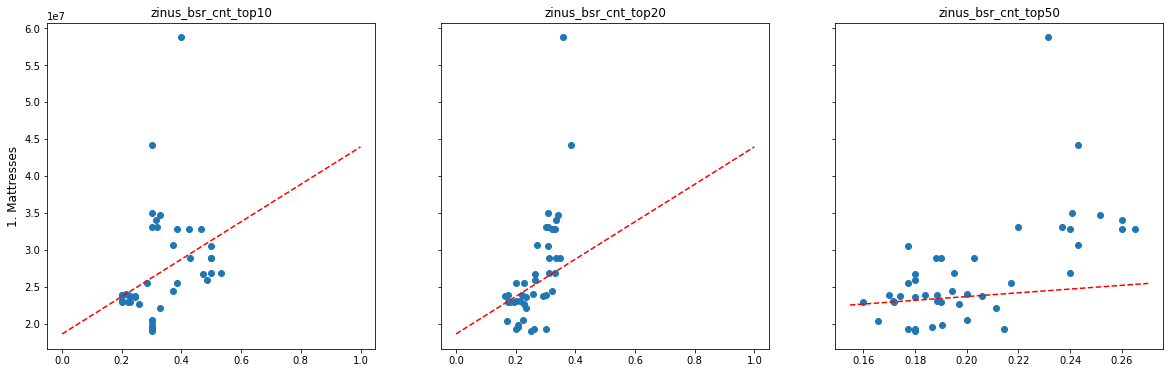

In [315]:
tmp_df = df_bsr_ms[df_bsr_ms.bsr_ctgry_label=='1. Mattresses']

# Outliers removed
fig,axs = plt.subplots(1,3,figsize=(20,6),sharey=True)
for k,predictor in enumerate(PREDICTORs):
    axs[k].scatter(tmp_df[predictor],tmp_df.MS)
    axs[k].set_title(predictor)
    abline(axs[k],df_ols.iloc[0].coeff,df_ols.iloc[0].intcpt)
    if k==0:
        axs[0].set_ylabel('1. Mattresses',fontsize=12)

## [Outlier removed] linear models per categories and bsr counts

In [306]:
cols = ['intcpt','coeff','pVal','R2']
df_ols_red = pd.DataFrame(columns=cols,\
                      index=pd.MultiIndex.from_product([CATEGORIEs,PREDICTORs],names=['bsr_category','bsr_cnt']))

for category in CATEGORIEs:
    for predictor in PREDICTORs:
        tmp_df = df_bsr_ms[df_bsr_ms.bsr_ctgry_label==category][['MS',predictor]].copy()
        
        masks = remove_outliers(tmp_df)
        tmp_df_red = tmp_df[masks['MS'] & masks[predictor]]
        
        expr = 'MS ~ ' + predictor
    
        model = sm.OLS.from_formula(expr, data=tmp_df_red)
        result = model.fit()

        intcpt = float(result.summary().tables[1].data[1][1])
        coeff = float(result.summary().tables[1].data[2][1])
        pVal = float(result.summary().tables[1].data[2][4])
        R2 = float(result.summary().tables[0].data[0][-1]) # R-squrared
        
        df_ols_red.loc[(category,predictor)] = [intcpt,coeff,pVal,R2]

        #print(f"model rank : %d" %model.rank)

/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 2 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: divide by zero encountered in true_divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: invalid value encountered in double_scalars
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1671: RuntimeWarning: divide by zero encountered in double_scalars
  return np.dot(wresid, wresid) / self.df_resid
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/stats/stat

In [307]:
df_ols_red

intcpt        coeff   pVal     R2
bsr_category        bsr_cnt                                                   
1. Mattresses       zinus_bsr_cnt_top10  16220000.0   29360000.0  0.013  0.202
                    zinus_bsr_cnt_top20  10010000.0   60150000.0    0.0  0.507
                    zinus_bsr_cnt_top50   3370000.0  110800000.0    0.0  0.352
2. Box Springs      zinus_bsr_cnt_top10   3092000.0    -972700.0  0.122  0.093
                    zinus_bsr_cnt_top20  12910000.0  -21300000.0  0.278  0.036
                    zinus_bsr_cnt_top50   1891000.0    1720000.0  0.556   0.01
3. Bed Frames       zinus_bsr_cnt_top10   5715000.0   12770000.0  0.047  0.114
                    zinus_bsr_cnt_top20   2685000.0   20710000.0  0.024  0.142
                    zinus_bsr_cnt_top50  27790000.0  -49630000.0    0.0  0.319
4. Beds             zinus_bsr_cnt_top10  11570000.0   -4464000.0  0.233  0.043
                    zinus_bsr_cnt_top20  13120000.0   -9672000.0  0.032  0.132
                    zinus_bsr_cnt_top50  14630000.0  -18910000.0  0.013  0.174
5. Mattress Toppers zinus_bsr_cnt_top10  -5215000.0  176900000.0    NaN    1.0
                    zinus_bsr_cnt_top20   6444000.0  -13890000.0  0.541   0.21
                    zinus_bsr_cnt_top50   9734000.0  -81900000.0  0.034  0.137
6. Sofas & Couches  zinus_bsr_cnt_top10   4542000.0    2517000.0  0.684   0.01
                    zinus_bsr_cnt_top20   6453000.0  -18600000.0  0.007  0.199
                    zinus_bsr_cnt_top50   2789000.0   31920000.0  0.049  0.109

In [319]:
df_ols_red[df_ols_red.pVal<0.05].index

MultiIndex([(      '1. Mattresses', 'zinus_bsr_cnt_top10'),
            (      '1. Mattresses', 'zinus_bsr_cnt_top20'),
            (      '1. Mattresses', 'zinus_bsr_cnt_top50'),
            (      '3. Bed Frames', 'zinus_bsr_cnt_top10'),
            (      '3. Bed Frames', 'zinus_bsr_cnt_top20'),
            (      '3. Bed Frames', 'zinus_bsr_cnt_top50'),
            (            '4. Beds', 'zinus_bsr_cnt_top20'),
            (            '4. Beds', 'zinus_bsr_cnt_top50'),
            ('5. Mattress Toppers', 'zinus_bsr_cnt_top50'),
            ( '6. Sofas & Couches', 'zinus_bsr_cnt_top20'),
            ( '6. Sofas & Couches', 'zinus_bsr_cnt_top50')],
           names=['bsr_category', 'bsr_cnt'])

### Plots

/var/folders/vd/pcfzbdv570j5qp_gjznyl9kc0000gp/T/ipykernel_21964/1195124710.py:4: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  mask = (df < upper) & (df > lower)
/var/folders/vd/pcfzbdv570j5qp_gjznyl9kc0000gp/T/ipykernel_21964/1195124710.py:4: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  mask = (df < upper) & (df > lower)
/var/folders/vd/pcfzbdv570j5qp_gjznyl9kc0000gp/T/ipykernel_21964/1195124710.py:4: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  mask = (df < upper) & (df >

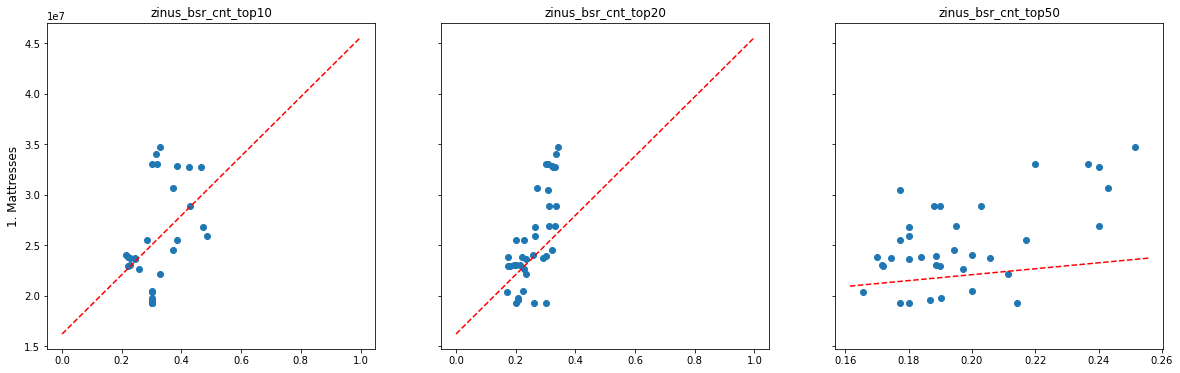

In [316]:
tmp_df = df_bsr_ms[df_bsr_ms.bsr_ctgry_label=='1. Mattresses']

# Outliers removed
fig,axs = plt.subplots(1,3,figsize=(20,6),sharey=True)
for k,predictor in enumerate(PREDICTORs):
    masks = remove_outliers(tmp_df)
    tmp_df_red = tmp_df[masks['MS'] & masks[predictor]]
    
    axs[k].scatter(tmp_df_red[predictor],tmp_df_red.MS)
    axs[k].set_title(predictor)
    abline(axs[k],df_ols_red.iloc[0].coeff,df_ols_red.iloc[0].intcpt)
    if k==0:
        axs[0].set_ylabel('1. Mattresses',fontsize=12)